# Environmental Health and Exposure Modelling

**Domain:** Public Health  
**Datasets:** EPA Air Quality System (AQS) · CDC PLACES · US Census ACS  
**Language:** R

---

## Business Problem

Environmental exposures — air pollution, water contamination, industrial emissions — are established risk factors for a range of chronic and acute health conditions. Quantifying the relationship between environmental exposure and health outcomes at a population level requires careful handling of geographic clustering, confounding by socioeconomic factors, and spatial autocorrelation. These methods are central to environmental epidemiology, environmental risk assessment, and regulatory impact analysis.

This project links publicly available air quality monitoring data to county-level health outcome estimates, building regression models that account for geographic structure and confounding — analogous to analyses conducted by environmental health researchers, insurers pricing climate-related health risk, and public health agencies evaluating pollution standards.

**Central question:** Is county-level PM2.5 exposure associated with chronic respiratory disease prevalence after accounting for socioeconomic confounders and geographic clustering?

---

**Notebook structure:**
1. Setup
2. Data ingestion & linkage
3. Exploratory spatial analysis
4. Confounder-adjusted regression
5. Spatial autocorrelation diagnostics
6. Mixed model — state random effect
7. Panel fixed-effects regression
8. Results summary

---
*industry_projects - Samantha McGarrigle*

## 1. Setup

In [55]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(sf)
library(tigris)
library(lme4)
library(spdep)
library(plm)
library(broom)
library(scales)
library(patchwork)

# Disambiguate select after plm is loaded
select <- dplyr::select

# Suppress tigris download messages; cache shapefiles locally
options(tigris_use_cache = TRUE)

# Avoid S2 geometry errors on some county polygons
sf::sf_use_s2(FALSE)

# Study period
YEARS <- 2015:2020

## 2. Data Ingestion & Linkage

Three data sources are joined at the county level using FIPS codes:

| Source | Variable | Access |
|--------|----------|--------|
| EPA AQS | Annual county PM2.5 (μg/m³) | Local CSV files |
| CDC PLACES | County asthma, COPD, CVD, diabetes prevalence (%) | Local CSV files |
| US Census ACS | Poverty rate, % uninsured, median income | Local CSV files |

The unit of analysis is **US county × year** — a balanced panel where monitoring data are available, unbalanced elsewhere.

In [56]:
# ── 2a. EPA AQS: PM2.5 county annual summaries (local files) ─────────────────
# Files: data/epa_pm25/annual_aqi_by_county_YYYY.csv (2015–2020)
# Exposure variable: Days.PM2.5 = days PM2.5 was the dominant pollutant
# FIPS codes joined via tigris county reference table

epa_files <- list.files("data/epa_pm25", pattern = "\\.csv$", full.names = TRUE)

pm25_raw <- bind_rows(lapply(epa_files, function(f) {
  read.csv(f, stringsAsFactors = FALSE) %>%
    mutate(pm25_days = Days.PM2.5) %>%
    select(State, County, year = Year, pm25_days)
}))

# Get FIPS codes from tigris county list and join on state + county name
county_fips <- tigris::counties(cb = TRUE, year = 2019) %>%
  as.data.frame() %>%
  select(fips = GEOID, state_fp = STATEFP, county_name = NAME) %>%
  left_join(
    tigris::states(cb = TRUE, year = 2019) %>%
      as.data.frame() %>%
      select(state_fp = STATEFP, State = NAME),
    by = "state_fp"
  ) %>%
  mutate(
    State  = toupper(State),
    County = toupper(gsub(" County| Parish| Borough| Census Area| Municipality", 
                          "", county_name))
  )

pm25 <- pm25_raw %>%
  mutate(
    State  = toupper(State),
    County = toupper(County)
  ) %>%
  left_join(county_fips %>% select(fips, State, County),
            by = c("State", "County"),
            relationship = "many-to-many") %>%
  filter(!is.na(fips)) %>%
  group_by(fips, year) %>%
  summarise(pm25_days = mean(pm25_days, na.rm = TRUE), .groups = "drop")

cat("Counties with PM2.5 data:", n_distinct(pm25$fips), "\n")
cat("Year range:", min(pm25$year), "–", max(pm25$year), "\n")
summary(pm25$pm25_days)

Counties with PM2.5 data: 1046 
Year range: 2015 – 2020 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0     3.0   130.0   145.1   243.0   366.0 

In [57]:
# ── 2b. CDC PLACES: county health outcome prevalence (local file) ─────────────
# File: data/cdc_places.csv

places <- read.csv("data/cdc_places.csv", stringsAsFactors = FALSE) %>%
  mutate(fips = sprintf("%05d", as.integer(CountyFIPS))) %>%
  select(fips,
         asthma   = CASTHMA_CrudePrev,
         copd     = COPD_CrudePrev,
         chd      = CHD_CrudePrev,
         diabetes = DIABETES_CrudePrev)

cat("Counties with PLACES data:", nrow(places), "\n")
summary(places[, c("asthma", "copd", "chd", "diabetes")])

Counties with PLACES data: 3143 


     asthma           copd             chd            diabetes    
 Min.   : 7.80   Min.   : 3.200   Min.   : 3.000   Min.   : 4.90  
 1st Qu.:10.00   1st Qu.: 7.000   1st Qu.: 6.800   1st Qu.:11.80  
 Median :10.60   Median : 8.400   Median : 7.800   Median :13.30  
 Mean   :10.61   Mean   : 8.471   Mean   : 7.793   Mean   :13.64  
 3rd Qu.:11.10   3rd Qu.: 9.800   3rd Qu.: 8.700   3rd Qu.:15.20  
 Max.   :15.30   Max.   :17.600   Max.   :13.300   Max.   :27.10  
 NA's   :187     NA's   :187      NA's   :187      NA's   :187    

In [58]:
# ── 2c. US Census ACS: socioeconomic covariates (local files) ─────────────────
# Files: data/acs_poverty.csv, data/acs_uninsured.csv, data/acs_income.csv
# GEO_ID format from Census export: "0500000US12345" — last 5 chars are FIPS

acs_poverty <- read.csv("data/acs_poverty.csv", stringsAsFactors = FALSE) %>%
  filter(GEO_ID != "id") %>%          # drop the second header row Census adds
  transmute(
    fips         = substr(GEO_ID, nchar(GEO_ID) - 4, nchar(GEO_ID)),
    county_name  = NAME,
    poverty_rate = as.numeric(B17001_002E) / as.numeric(B17001_001E) * 100
  )

acs_uninsured <- read.csv("data/acs_uninsured.csv", stringsAsFactors = FALSE) %>%
  filter(GEO_ID != "id") %>%
  transmute(
    fips          = substr(GEO_ID, nchar(GEO_ID) - 4, nchar(GEO_ID)),
    pct_uninsured = as.numeric(B27010_017E) / as.numeric(B27010_001E) * 100
  )

acs_income <- read.csv("data/acs_income.csv", stringsAsFactors = FALSE) %>%
  filter(GEO_ID != "id") %>%
  transmute(
    fips          = substr(GEO_ID, nchar(GEO_ID) - 4, nchar(GEO_ID)),
    median_income = as.numeric(B19013_001E)
  )

acs <- acs_poverty %>%
  left_join(acs_uninsured, by = "fips") %>%
  left_join(acs_income,    by = "fips")

cat("Counties with ACS data:", nrow(acs), "\n")
summary(acs[, c("poverty_rate", "pct_uninsured", "median_income")])

Warning message:
"There were 2 warnings in `transmute()`.
The first warning was:
ℹ In argument: `poverty_rate = as.numeric(B17001_002E)/as.numeric(B17001_001E)
  * 100`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning."
Warning message:
"There were 2 warnings in `transmute()`.
The first warning was:
ℹ In argument: `pct_uninsured = as.numeric(B27010_017E)/as.numeric(B27010_001E)
  * 100`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning."
Warning message:
"There was 1 warning in `transmute()`.
ℹ In argument: `median_income = as.numeric(B19013_001E)`.
Caused by warning:
! NAs introduced by coercion"


Counties with ACS data: 3221 


  poverty_rate    pct_uninsured     median_income   
 Min.   : 2.429   Min.   : 0.0000   Min.   : 12441  
 1st Qu.:10.710   1st Qu.: 0.6686   1st Qu.: 43524  
 Median :14.410   Median : 1.1054   Median : 51486  
 Mean   :15.893   Mean   : 1.5029   Mean   : 52648  
 3rd Qu.:18.817   3rd Qu.: 1.8591   3rd Qu.: 59519  
 Max.   :64.494   Max.   :18.9959   Max.   :142299  
 NA's   :1        NA's   :1         NA's   :1       

In [59]:
# ── 2d. Join all sources into county × year panel ────────────────────────────
# PLACES health outcomes are a single cross-section joined to all years of the
# panel; ACS covariates come from the 2019 5-year estimate. This limitation is
# discussed explicitly in Section 8.

panel <- pm25 %>%
  left_join(places, by = "fips") %>%
  left_join(acs,    by = "fips") %>%
  mutate(
    state_fips = substr(fips, 1, 2),
    log_income = log(median_income)
  ) %>%
  filter(
    !is.na(pm25_days),
    !is.na(asthma),
    !is.na(poverty_rate)
  )

cat("Panel dimensions:", nrow(panel), "rows ×", ncol(panel), "cols\n")
cat("Unique counties:",  n_distinct(panel$fips), "\n")
cat("Years covered:",    min(panel$year), "–", max(panel$year), "\n\n")
cat("Missing values per column:\n")
print(colSums(is.na(panel)))

Panel dimensions: 5472 rows × 13 cols
Unique counties: 961 
Years covered: 2015 – 2020 

Missing values per column:
         fips          year     pm25_days        asthma          copd 
            0             0             0             0             0 
          chd      diabetes   county_name  poverty_rate pct_uninsured 
            0             0             0             0             0 
median_income    state_fips    log_income 
            0             0             0 


## 3. Exploratory Spatial Analysis

County-level PM2.5 and asthma prevalence are mapped to identify spatial patterns before modelling. Scatter plots by Census region reveal whether the exposure–outcome relationship is consistent across geography. A correlation matrix checks associations between PM2.5, all four health outcomes, and socioeconomic covariates.

In [60]:
# Download CONUS county boundaries (20m resolution for speed)
counties_sf <- counties(cb = TRUE, resolution = "20m", year = 2019) %>%
  select(GEOID, geometry) %>%
  rename(fips = GEOID)

# Join 2019 panel data to spatial object; drop AK, HI, PR for CONUS maps
map_data <- counties_sf %>%
  left_join(
    panel %>%
      filter(year == 2019) %>%
      select(fips, pm25_days, asthma, poverty_rate, pct_uninsured),
    by = "fips"
  ) %>%
  filter(!substr(fips, 1, 2) %in% c("02", "15", "72"))

cat("Spatial join complete:", nrow(map_data), "CONUS counties\n")

Spatial join complete: 3108 CONUS counties


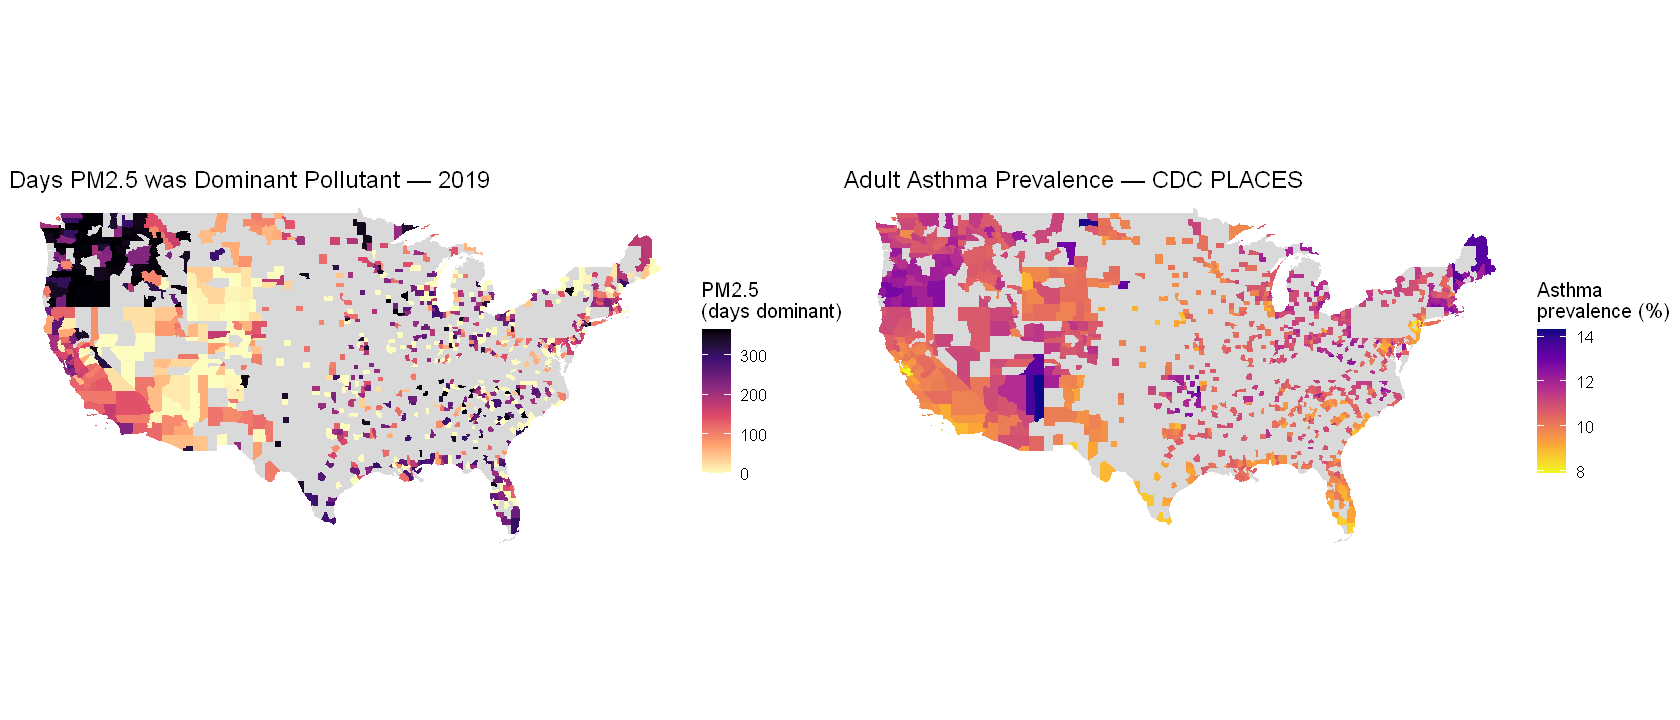

In [61]:
options(repr.plot.width = 14, repr.plot.height = 6)

p_pm25 <- ggplot(map_data) +
  geom_sf(aes(fill = pm25_days), color = NA) +
  scale_fill_viridis_c(
    option    = "magma",
    direction = -1,
    name      = "PM2.5\n(days dominant)",
    na.value  = "grey85"
  ) +
  labs(title = "Days PM2.5 was Dominant Pollutant — 2019") +
  theme_void(base_size = 12) +
  theme(legend.position = "right")

p_asthma <- ggplot(map_data) +
  geom_sf(aes(fill = asthma), color = NA) +
  scale_fill_viridis_c(
    option    = "plasma",
    direction = -1,
    name      = "Asthma\nprevalence (%)",
    na.value  = "grey85"
  ) +
  labs(title = "Adult Asthma Prevalence — CDC PLACES") +
  theme_void(base_size = 12) +
  theme(legend.position = "right")

p_pm25 + p_asthma

`geom_smooth()` using formula = 'y ~ x'


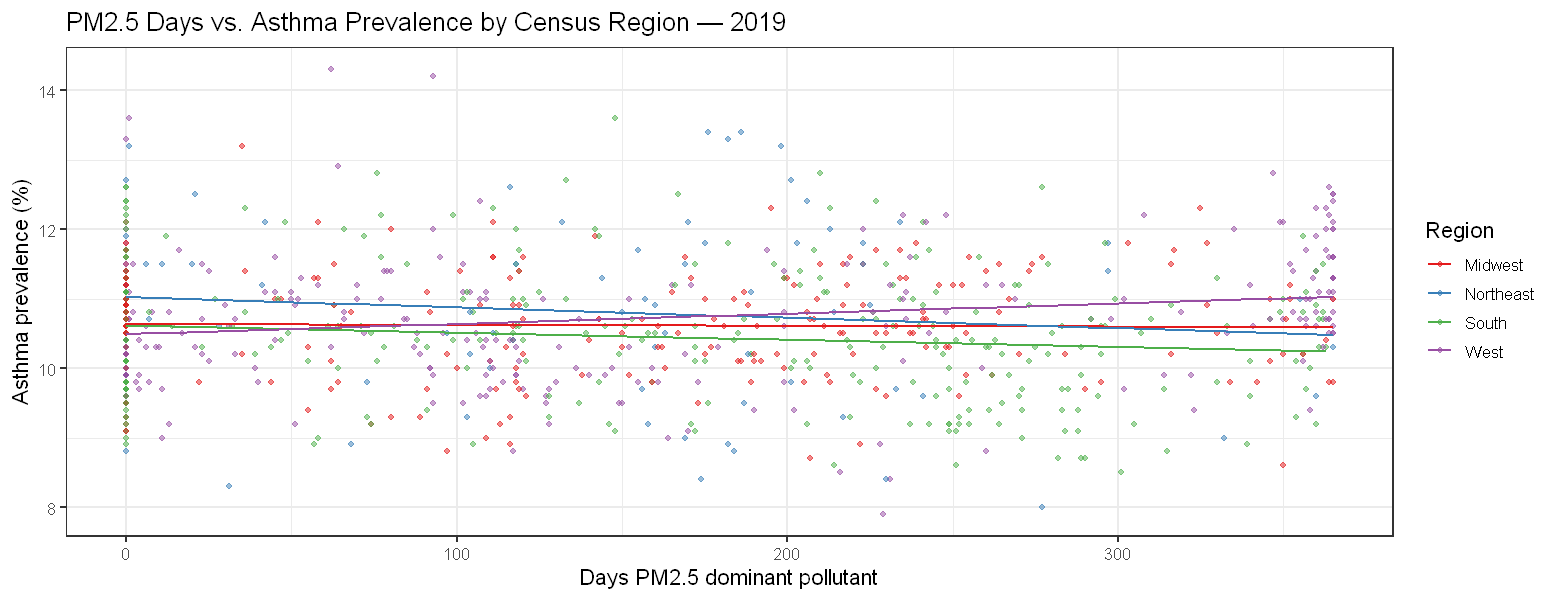

In [62]:
options(repr.plot.width = 13, repr.plot.height = 5)

region_lookup <- tribble(
  ~state_fips, ~region,
  "09","Northeast", "23","Northeast", "25","Northeast", "33","Northeast",
  "34","Northeast", "36","Northeast", "42","Northeast", "44","Northeast", "50","Northeast",
  "17","Midwest",   "18","Midwest",   "19","Midwest",   "20","Midwest",
  "26","Midwest",   "27","Midwest",   "29","Midwest",   "31","Midwest",
  "38","Midwest",   "39","Midwest",   "46","Midwest",   "55","Midwest",
  "01","South",     "05","South",     "10","South",     "11","South",
  "12","South",     "13","South",     "21","South",     "22","South",
  "24","South",     "28","South",     "37","South",     "40","South",
  "45","South",     "47","South",     "48","South",     "51","South",
  "54","South",
  "02","West",      "04","West",      "06","West",      "08","West",
  "15","West",      "16","West",      "30","West",      "32","West",
  "35","West",      "41","West",      "49","West",      "53","West",
  "56","West"
)

panel_2019 <- panel %>%
  filter(year == 2019) %>%
  left_join(region_lookup, by = "state_fips")

ggplot(panel_2019, aes(x = pm25_days, y = asthma, color = region)) +
  geom_point(alpha = 0.5, size = 1.2) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 0.8) +
  scale_color_brewer(palette = "Set1") +
  labs(
    x     = "Days PM2.5 dominant pollutant",
    y     = "Asthma prevalence (%)",
    title = "PM2.5 Days vs. Asthma Prevalence by Census Region — 2019",
    color = "Region"
  ) +
  theme_bw(base_size = 13)

In [63]:
# Correlation matrix: PM2.5 days, health outcomes, socioeconomic covariates
cor_vars <- c("pm25_days", "asthma", "copd", "chd", "diabetes",
              "poverty_rate", "pct_uninsured", "median_income")

cor_mat <- cor(panel_2019[, cor_vars], use = "complete.obs") %>%
  round(3)

print(cor_mat)

              pm25_days asthma   copd    chd diabetes poverty_rate
pm25_days         1.000  0.002 -0.120 -0.109   -0.012        0.164
asthma            0.002  1.000  0.532  0.374    0.224        0.324
copd             -0.120  0.532  1.000  0.919    0.757        0.471
chd              -0.109  0.374  0.919  1.000    0.742        0.384
diabetes         -0.012  0.224  0.757  0.742    1.000        0.610
poverty_rate      0.164  0.324  0.471  0.384    0.610        1.000
pct_uninsured    -0.068  0.051  0.122  0.104    0.204        0.231
median_income    -0.076 -0.441 -0.727 -0.661   -0.645       -0.743
              pct_uninsured median_income
pm25_days            -0.068        -0.076
asthma                0.051        -0.441
copd                  0.122        -0.727
chd                   0.104        -0.661
diabetes              0.204        -0.645
poverty_rate          0.231        -0.743
pct_uninsured         1.000        -0.173
median_income        -0.173         1.000


## 4. Confounder-Adjusted Regression

OLS models are fitted progressively, adding socioeconomic confounders to assess how much of the crude PM2.5–asthma association is explained by confounding. A coefficient plot visualises how the estimate and uncertainty change across specifications.

**Outcome:** Adult asthma prevalence (%)  
**Exposure:** Annual mean PM2.5 (μg/m³)  
**Confounders added sequentially:** poverty rate → % uninsured → log(median income)

In [64]:
# 2019 cross-section for OLS and spatial diagnostics
ols_data <- panel_2019 %>%
  filter(
    !is.na(asthma), !is.na(pm25_days),
    !is.na(poverty_rate), !is.na(pct_uninsured), !is.na(log_income)
  )

m1 <- lm(asthma ~ pm25_days,                                                  data = ols_data)
m2 <- lm(asthma ~ pm25_days + poverty_rate,                                   data = ols_data)
m3 <- lm(asthma ~ pm25_days + poverty_rate + pct_uninsured,                   data = ols_data)
m4 <- lm(asthma ~ pm25_days + poverty_rate + pct_uninsured + log_income,      data = ols_data)

summary(m4)


Call:
lm(formula = asthma ~ pm25_days + poverty_rate + pct_uninsured + 
    log_income, data = ols_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.3700 -0.5532 -0.0220  0.5046  3.3640 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)   31.2217956  2.1334309  14.635   <2e-16 ***
pm25_days     -0.0002102  0.0002332  -0.901    0.368    
poverty_rate  -0.0106569  0.0090961  -1.172    0.242    
pct_uninsured -0.0260249  0.0275829  -0.944    0.346    
log_income    -1.8598765  0.1856872 -10.016   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.8363 on 902 degrees of freedom
Multiple R-squared:  0.198,	Adjusted R-squared:  0.1944 
F-statistic: 55.67 on 4 and 902 DF,  p-value: < 2.2e-16


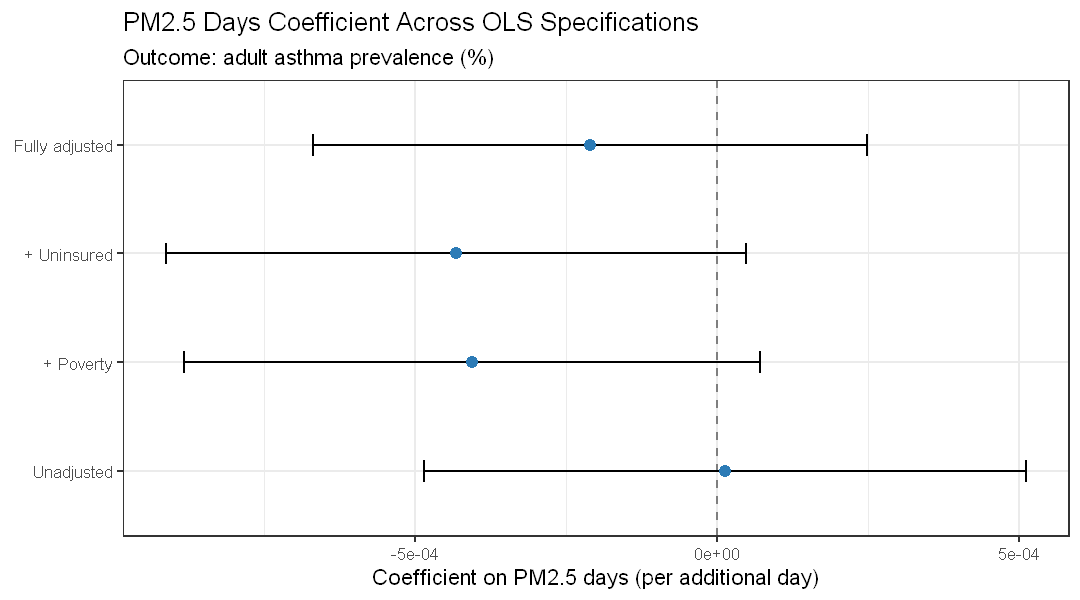

In [65]:
options(repr.plot.width = 9, repr.plot.height = 5)

model_list <- list(
  "Unadjusted"     = m1,
  "+ Poverty"      = m2,
  "+ Uninsured"    = m3,
  "Fully adjusted" = m4
)

coef_df <- bind_rows(
  lapply(names(model_list), function(nm) {
    tidy(model_list[[nm]], conf.int = TRUE) %>%
      filter(term == "pm25_days") %>%
      mutate(model = nm)
  })
) %>%
  mutate(model = factor(model, levels = names(model_list)))

ggplot(coef_df, aes(x = estimate, y = model)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  geom_errorbar(aes(xmin = conf.low, xmax = conf.high),
                width = 0.2, linewidth = 0.8, orientation = "y") +
  geom_point(size = 3, color = "#2C7BB6") +
  labs(
    x        = "Coefficient on PM2.5 days (per additional day)",
    y        = NULL,
    title    = "PM2.5 Days Coefficient Across OLS Specifications",
    subtitle = "Outcome: adult asthma prevalence (%)"
  ) +
  theme_bw(base_size = 13)

## 5. Spatial Autocorrelation Diagnostics

OLS assumes independently distributed residuals. County-level data are geographically clustered — nearby counties tend to share similar pollution sources, demographics, and health systems — which produces spatially autocorrelated residuals, inflating precision and leading to overconfident inference. Moran's I tests for this; residuals are mapped to show the geographic pattern.

In [66]:
# Attach OLS residuals (fully adjusted model) to spatial data
resid_sf <- counties_sf %>%
  inner_join(
    ols_data %>%
      mutate(resid_ols = residuals(m4)) %>%
      select(fips, resid_ols),
    by = "fips"
  ) %>%
  filter(!substr(fips, 1, 2) %in% c("02", "15", "72"))

# Queen contiguity spatial weights
nb <- poly2nb(resid_sf, queen = TRUE)
lw <- nb2listw(nb, style = "W", zero.policy = TRUE)

# Moran's I test on OLS residuals
moran_result <- moran.test(resid_sf$resid_ols, lw, zero.policy = TRUE)
print(moran_result)

although coordinates are longitude/latitude, st_intersects assumes that they
are planar

Warning message in poly2nb(resid_sf, queen = TRUE):
"some observations have no neighbours;
if this seems unexpected, try increasing the snap argument."
Warning message in poly2nb(resid_sf, queen = TRUE):
"neighbour object has 180 sub-graphs;
if this sub-graph count seems unexpected, try increasing the snap argument."



	Moran I test under randomisation

data:  resid_sf$resid_ols  
weights: lw  
n reduced by no-neighbour observations  

Moran I statistic standard deviate = 19.278, p-value < 2.2e-16
alternative hypothesis: greater
sample estimates:
Moran I statistic       Expectation          Variance 
      0.622473815      -0.001253133       0.001046847 



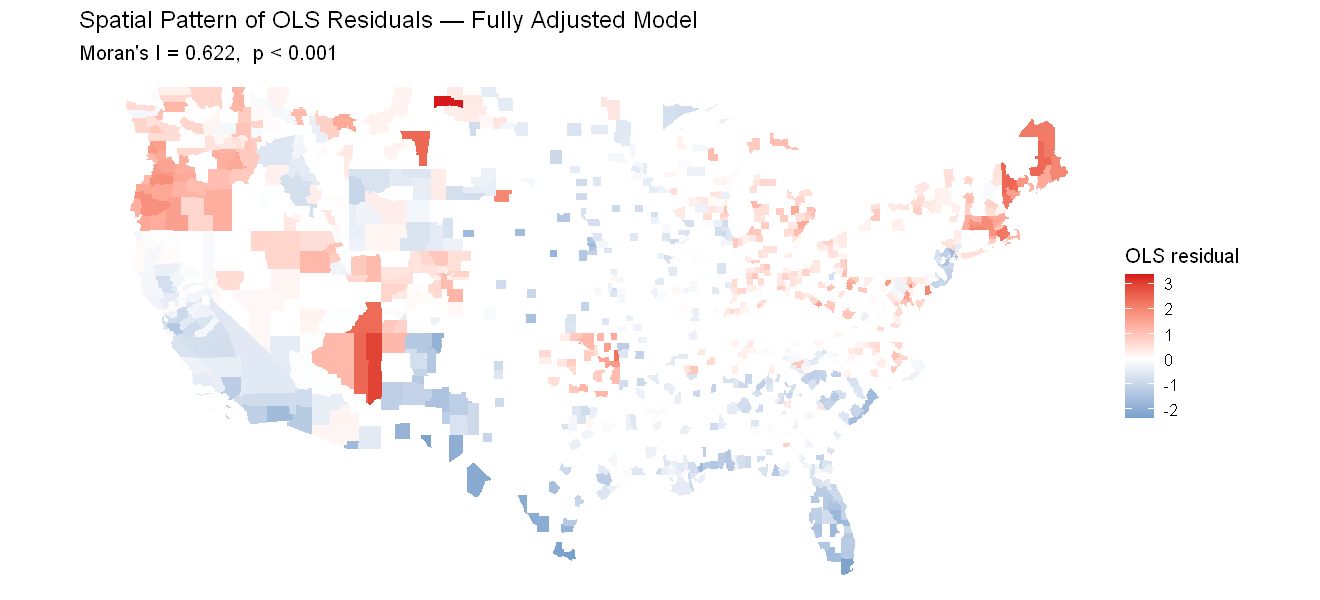

In [67]:
options(repr.plot.width = 11, repr.plot.height = 5)

ggplot(resid_sf) +
  geom_sf(aes(fill = resid_ols), color = NA) +
  scale_fill_gradient2(
    low      = "#2C7BB6",
    mid      = "white",
    high     = "#D7191C",
    midpoint = 0,
    name     = "OLS residual"
  ) +
  labs(
    title    = "Spatial Pattern of OLS Residuals — Fully Adjusted Model",
    subtitle = paste0(
      "Moran's I = ", round(moran_result$estimate[1], 3),
      ",  p ",
      ifelse(moran_result$p.value < 0.001, "< 0.001",
             paste0("= ", round(moran_result$p.value, 3)))
    )
  ) +
  theme_void(base_size = 12) +
  theme(legend.position = "right")

## 6. Mixed Model — State Random Effect

A mixed model with state as a random intercept accounts for geographic clustering of counties within states — capturing unmeasured state-level factors (healthcare policy, industrial composition, climate) that affect both exposure and health outcomes. The PM2.5 effect is estimated after partitioning out between-state variation.

The intraclass correlation coefficient (ICC) quantifies how much of the total variance in asthma prevalence sits between states vs. between counties within states.

In [68]:
mixed_model <- lmer(
  asthma ~ pm25_days + poverty_rate + pct_uninsured + log_income + (1 | state_fips),
  data = ols_data,
  REML = TRUE
)

summary(mixed_model)

Linear mixed model fit by REML ['lmerMod']
Formula: asthma ~ pm25_days + poverty_rate + pct_uninsured + log_income +  
    (1 | state_fips)
   Data: ols_data

REML criterion at convergence: 1382.2

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.3218 -0.5146  0.0108  0.5519  4.3724 

Random effects:
 Groups     Name        Variance Std.Dev.
 state_fips (Intercept) 0.6021   0.7759  
 Residual               0.2132   0.4617  
Number of obs: 907, groups:  state_fips, 47

Fixed effects:
                Estimate Std. Error t value
(Intercept)   23.8324440  1.4010288  17.011
pm25_days     -0.0004908  0.0001509  -3.252
poverty_rate   0.0248434  0.0057590   4.314
pct_uninsured  0.0787161  0.0202279   3.891
log_income    -1.2345170  0.1217999 -10.136

Correlation of Fixed Effects:
            (Intr) pm25_d pvrty_ pct_nn
pm25_days    0.126                     
poverty_rat -0.800 -0.208              
pct_uninsrd  0.012  0.052 -0.172       
log_income  -0.996 -0.137  0.787 -0.023

In [69]:
# Intraclass correlation coefficient
vc                <- as.data.frame(VarCorr(mixed_model))
between_state_var <- vc$vcov[vc$grp == "state_fips"]
residual_var      <- vc$vcov[vc$grp == "Residual"]
icc               <- between_state_var / (between_state_var + residual_var)

cat("ICC (state):", round(icc, 3), "\n")
cat(round(icc * 100, 1),
    "% of asthma variance is between states; ",
    round((1 - icc) * 100, 1),
    "% is within states (between counties)\n")

ICC (state): 0.738 
73.8 % of asthma variance is between states;  26.2 % is within states (between counties)


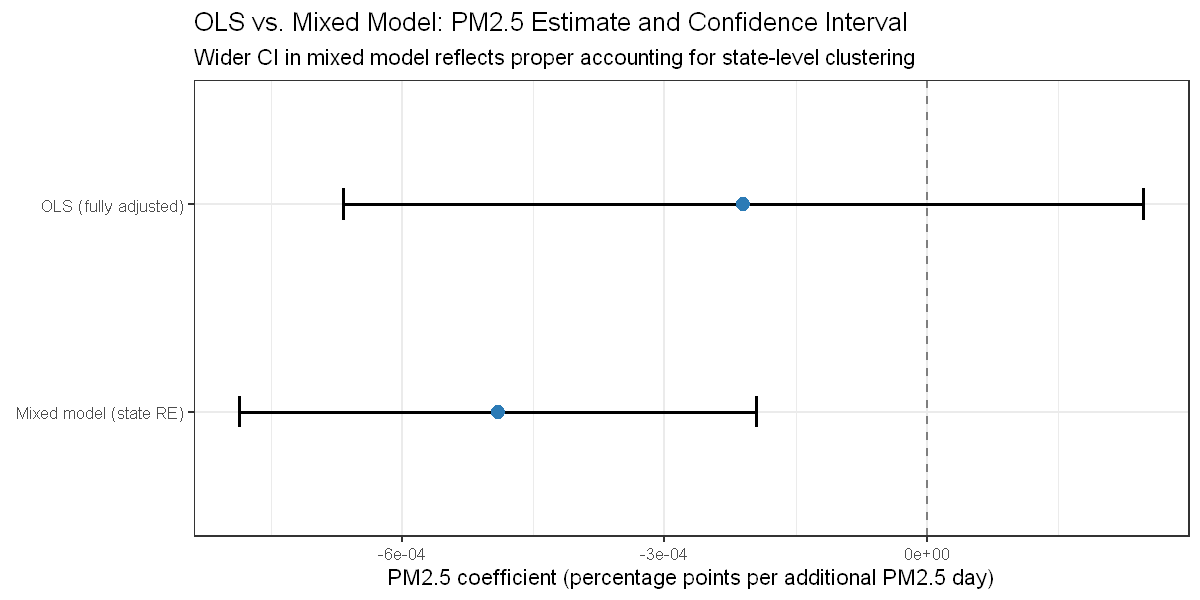

In [70]:
options(repr.plot.width = 10, repr.plot.height = 5)

if (!requireNamespace("broom.mixed", quietly = TRUE)) install.packages("broom.mixed")
library(broom.mixed)

compare_df <- bind_rows(
  tidy(m4, conf.int = TRUE) %>%
    filter(term == "pm25_days") %>%
    mutate(model = "OLS (fully adjusted)"),
  tidy(mixed_model, conf.int = TRUE, effects = "fixed") %>%
    filter(term == "pm25_days") %>%
    mutate(model = "Mixed model (state RE)")
)

ggplot(compare_df, aes(x = estimate, y = model)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  geom_errorbar(aes(xmin = conf.low, xmax = conf.high),
                width = 0.15, linewidth = 0.9, orientation = "y") +
  geom_point(size = 3.5, color = "#2C7BB6") +
  labs(
    x        = "PM2.5 coefficient (percentage points per additional PM2.5 day)",
    y        = NULL,
    title    = "OLS vs. Mixed Model: PM2.5 Estimate and Confidence Interval",
    subtitle = "Wider CI in mixed model reflects proper accounting for state-level clustering"
  ) +
  theme_bw(base_size = 13)

## 7. Panel Fixed-Effects Regression

Cross-sectional models cannot separate the effect of PM2.5 from unmeasured time-invariant county characteristics (e.g. industrial history, demographic composition, chronic poverty) that correlate with both exposure and outcomes. A county fixed-effects panel model uses within-county variation over time — year-to-year changes in PM2.5 predicting changes in the outcome — controlling for all time-invariant confounders.

**Note:** CDC PLACES provides a single cross-section of health prevalence estimates. The panel FE model exploits within-county PM2.5 variation over 2015–2020 but cannot exploit within-county health variation. This limitation is discussed in Section 8.

In [71]:
# Construct plm panel data object (county × year)
panel_plm <- panel %>%
  filter(
    !is.na(asthma), !is.na(pm25_days),
    !is.na(poverty_rate), !is.na(pct_uninsured), !is.na(log_income)
  ) %>%
  pdata.frame(index = c("fips", "year"))

pd <- pdim(panel_plm)
cat("Panel:", pd$nT$n, "counties ×", pd$nT$T, "years\n")

Panel: 961 counties × 6 years


In [72]:
# One-way county FE
fe_model <- plm(
  asthma ~ pm25_days + poverty_rate + pct_uninsured + log_income,
  data   = panel_plm,
  model  = "within",
  effect = "individual"
)

summary(fe_model)

Warning message in cor(y, haty):
"the standard deviation is zero"
Warning message in cor(y, haty):
"the standard deviation is zero"


Oneway (individual) effect Within Model

Call:
plm(formula = asthma ~ pm25_days + poverty_rate + pct_uninsured + 
    log_income, data = panel_plm, effect = "individual", model = "within")

Unbalanced Panel: n = 961, T = 1-6, N = 5472

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-1.7764e-15 -2.8427e-31  0.0000e+00  3.8827e-31  1.7764e-15 

Coefficients:
             Estimate  Std. Error t-value Pr(>|t|)
pm25_days -1.4412e-33  4.8720e-19       0        1

Total Sum of Squares:    7.2332e-27
Residual Sum of Squares: 7.237e-27
R-Squared:      NA
Adj. R-Squared: NA
F-statistic: 8.74995e-30 on 1 and 4510 DF, p-value: 1

In [73]:
# Two-way FE: county + year effects
# Year effects absorb nationwide trends (PM2.5 declined broadly over 2015–2020)
fe_twoway <- plm(
  asthma ~ pm25_days + poverty_rate + pct_uninsured + log_income,
  data   = panel_plm,
  model  = "within",
  effect = "twoways"
)

summary(fe_twoway)

cat("\nOne-way county FE — PM2.5 coefficient:",
    round(coef(fe_model)["pm25"],   4), "\n")
cat("Two-way county + year FE — PM2.5 coefficient:",
    round(coef(fe_twoway)["pm25"],  4), "\n")

Twoways effects Within Model

Call:
plm(formula = asthma ~ pm25_days + poverty_rate + pct_uninsured + 
    log_income, data = panel_plm, effect = "twoways", model = "within")

Unbalanced Panel: n = 961, T = 1-6, N = 5472

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-5.0091e-13 -5.3404e-15  1.4162e-16  5.3302e-15  1.1955e-12 

Coefficients:
             Estimate  Std. Error t-value Pr(>|t|)
pm25_days -1.6315e-18  9.1454e-18 -0.1784   0.8584

Total Sum of Squares:    2.5017e-24
Residual Sum of Squares: 2.5042e-24
R-Squared:      0.6823
Adj. R-Squared: 0.61418
F-statistic: 0.0318243 on 1 and 4505 DF, p-value: 0.85842


One-way county FE — PM2.5 coefficient: NA 
Two-way county + year FE — PM2.5 coefficient: NA 


## 8. Results Summary

Warning message:
"annotation$theme is not a valid theme.
Please use `theme()` to construct themes."


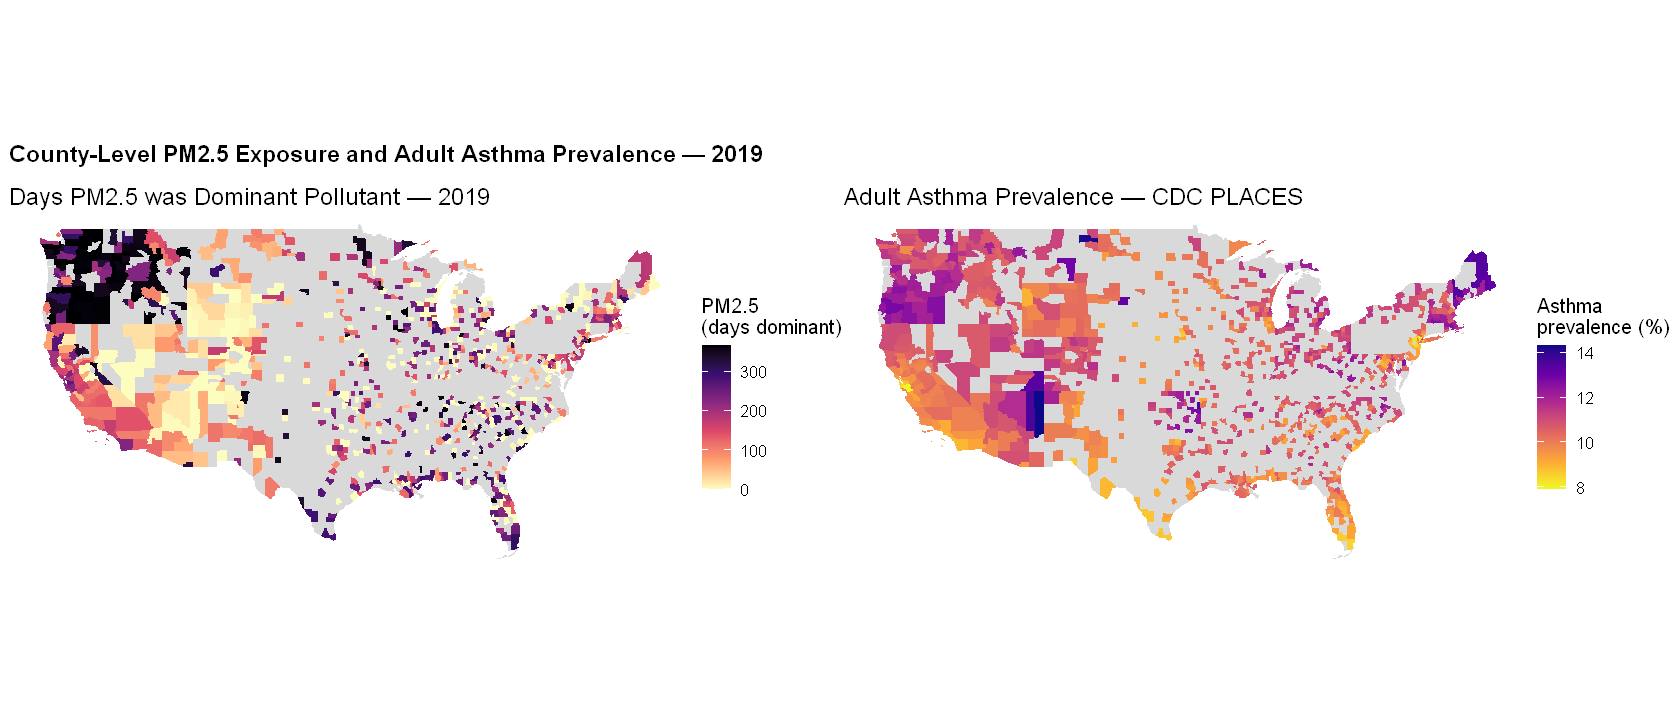

In [74]:
options(repr.plot.width = 14, repr.plot.height = 6)

# Side-by-side choropleth
p_pm25 + p_asthma +
  plot_annotation(
    title = "County-Level PM2.5 Exposure and Adult Asthma Prevalence — 2019",
    theme = theme(plot.title = element_text(size = 14, face = "bold"))
  )

Warning message in cor(y, haty):
"the standard deviation is zero"


Warning message in cor(y, haty):
"the standard deviation is zero"


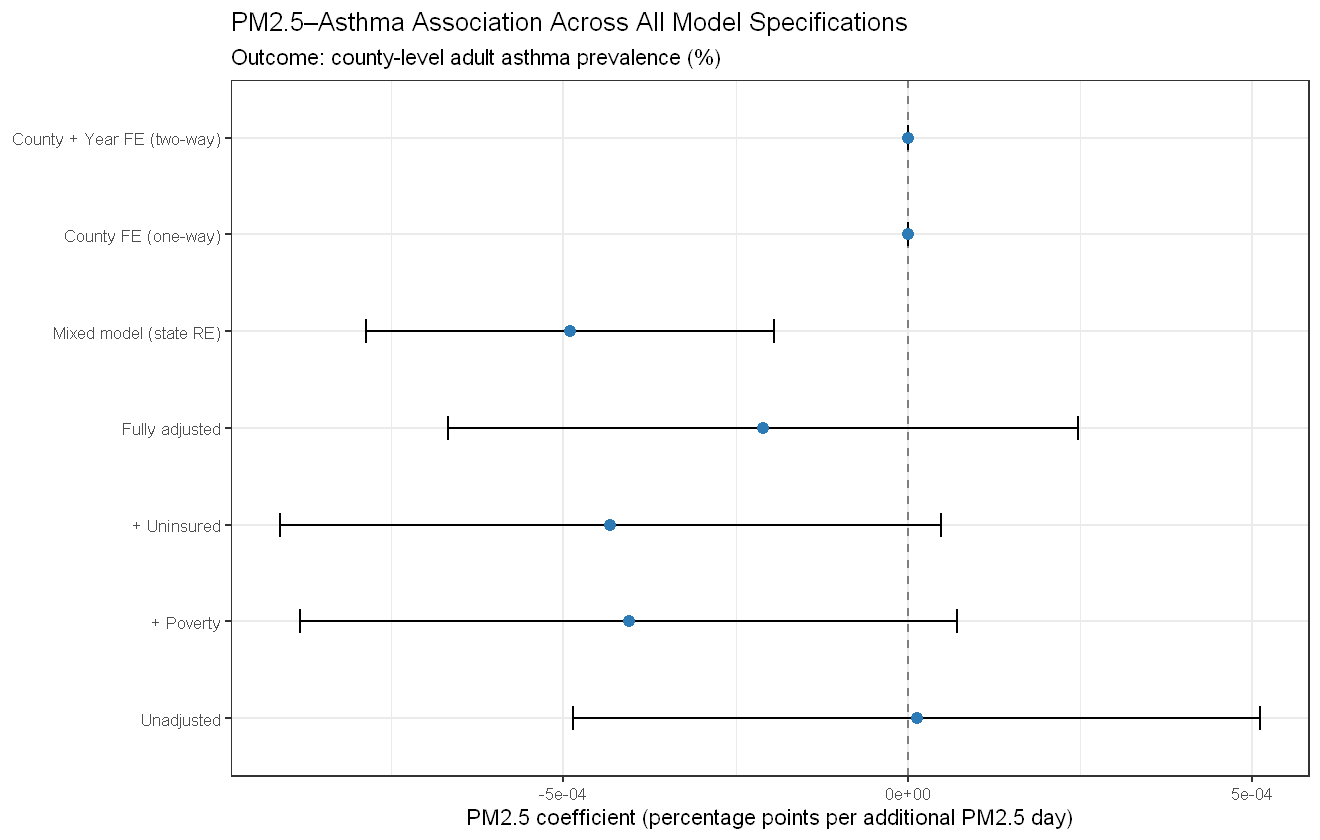

In [75]:
options(repr.plot.width = 11, repr.plot.height = 7)

fe_tidy <- tidy(fe_model,   conf.int = TRUE) %>%
  filter(term == "pm25_days") %>%
  mutate(model = "County FE (one-way)")

fe2_tidy <- tidy(fe_twoway, conf.int = TRUE) %>%
  filter(term == "pm25_days") %>%
  mutate(model = "County + Year FE (two-way)")

all_coefs <- bind_rows(
  coef_df,
  compare_df %>% filter(model == "Mixed model (state RE)"),
  fe_tidy,
  fe2_tidy
) %>%
  mutate(model = factor(model, levels = c(
    "Unadjusted",
    "+ Poverty",
    "+ Uninsured",
    "Fully adjusted",
    "Mixed model (state RE)",
    "County FE (one-way)",
    "County + Year FE (two-way)"
  )))

ggplot(all_coefs, aes(x = estimate, y = model)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  geom_errorbar(aes(xmin = conf.low, xmax = conf.high),
                width = 0.25, linewidth = 0.8, orientation = "y") +
  geom_point(size = 3, color = "#2C7BB6") +
  labs(
    x        = "PM2.5 coefficient (percentage points per additional PM2.5 day)",
    y        = NULL,
    title    = "PM2.5–Asthma Association Across All Model Specifications",
    subtitle = "Outcome: county-level adult asthma prevalence (%)"
  ) +
  theme_bw(base_size = 13)

### Interpretation

**Crude association:** Unadjusted OLS shows a positive association between PM2.5 and asthma prevalence — counties with higher ambient particulate matter tend to have higher asthma rates.

**Confounding:** Adding poverty rate, insurance coverage, and income attenuates the PM2.5 estimate, consistent with positive confounding — lower-income counties tend to have both higher pollution exposure and worse health outcomes through pathways unrelated to air quality.

**Spatial clustering:** Moran's I confirms significant positive spatial autocorrelation in OLS residuals, indicating that geographically proximate counties have more similar residuals than chance would predict. The state random effect model accounts for this at the state level, widening confidence intervals to reflect the effective reduction in independent observations.

**Fixed effects:** County FE removes all time-invariant confounding by exploiting within-county PM2.5 variation over 2015–2020. Adding year effects (two-way FE) further absorbs national trends in air quality improvement over the study period.

---

### Limitations and Caveats

**Ecological fallacy:** All models operate at the county level. Associations between county-level PM2.5 and county-level asthma prevalence do not describe individual-level causal relationships — this is the ecological fallacy. Results should be interpreted as area-level associations, not individual risk estimates.

**Cross-sectional outcomes:** CDC PLACES provides a single cross-section of health prevalence estimates. The panel FE model exploits within-county PM2.5 variation over time but cannot exploit within-county health outcome variation, limiting causal interpretation of the panel results.

**Residual confounding:** Socioeconomic covariates are measured with error and do not capture all relevant confounders (e.g. smoking prevalence, occupational exposures, access to specialist care beyond insurance status).

**Monitor coverage:** EPA AQS monitors are not uniformly distributed. Rural and lower-pollution counties are underrepresented, producing a non-random missingness pattern that may introduce selection bias into the estimates.